In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd "/content/drive/MyDrive/Rag_Distributed_testing/GPU-Cluster-Task-Distribution"

[Errno 2] No such file or directory: '/content/drive/MyDrive/Rag_Distributed_testing/GPU-Cluster-Task-Distribution'
/content


In [4]:
%cd "/content/drive/MyDrive/Rag_Distributed_testing"

/content/drive/MyDrive/Rag_Distributed_testing


In [5]:
!git clone -b integrated_1  --single-branch https://github.com/yousseffffahmedddd/GPU-Cluster-Task-Distribution.git integrated

Cloning into 'integrated'...
remote: Enumerating objects: 136, done.
remote: Counting objects: 100% (136/136), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 136 (delta 33), reused 114 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (136/136), 853.30 KiB | 12.93 MiB/s, done.
Resolving deltas: 100% (33/33), done.


In [6]:
!find /content/drive/MyDrive/Rag_Distributed_testing/integrated -name "requirements*.txt" -exec pip install -r {} \;

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 85.7 MB/s eta 0:00:00


In [45]:
import subprocess, os, time, threading

# Install + download Ollama binary (keep as-is)
!sudo apt-get install zstd -q
!curl -fsSL https://ollama.com/install.sh | sh

# ── Start 4 isolated Ollama instances, one per GPU worker ────
WORKER_PORTS = {
    "gpu-0": 11434,
    "gpu-1": 11435,
    "gpu-2": 11436,
    "gpu-3": 11437,
}

def start_ollama(port):
    env = os.environ.copy()
    env["OLLAMA_HOST"] = f"0.0.0.0:{port}"
    env["OLLAMA_MODELS"] = f"/tmp/ollama_models_{port}"   # isolated model dir per instance
    os.makedirs(env["OLLAMA_MODELS"], exist_ok=True)
    os.system(f"OLLAMA_HOST=0.0.0.0:{port} OLLAMA_MODELS=/tmp/ollama_models_{port} "
              f"ollama serve > /tmp/ollama_{port}.log 2>&1 &")

for port in WORKER_PORTS.values():
    t = threading.Thread(target=start_ollama, args=(port,))
    t.start()

print("⏳ Waiting for all 4 Ollama instances to initialize...")
time.sleep(15)
print("✅ 4 Ollama servers started:")
for wid, port in WORKER_PORTS.items():
    print(f"   {wid}  →  http://localhost:{port}")

Reading package lists...
Building dependency tree...
Reading state information...
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to remove and 100 not upgraded.
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
⏳ Waiting for all 4 Ollama instances to initialize...
✅ 4 Ollama servers started:
   gpu-0  →  http://localhost:11434
   gpu-1  →  http://localhost:11435
   gpu-2  →  http://localhost:11436
   gpu-3  →  http://localhost:11437


In [46]:
import sys, subprocess

WORKER_PORTS = {
    "gpu-0": 11434,
    "gpu-1": 11435,
    "gpu-2": 11436,
    "gpu-3": 11437,
}

print("📥 Pulling llama3.2:1b into all 4 Ollama instances...")
print("=" * 55)

for wid, port in WORKER_PORTS.items():
    print(f"\n  → Pulling into {wid} (port {port})...")
    env = os.environ.copy()
    env["OLLAMA_HOST"] = f"http://localhost:{port}"
    proc = subprocess.run(
        ["ollama", "pull", "llama3.2:1b"],
        env=env,
        capture_output=True, text=True
    )
    if "success" in proc.stdout or proc.returncode == 0:
        print(f"  ✅ {wid} ready")
    else:
        print(f"  ❌ {wid} failed: {proc.stderr[:200]}")

📥 Pulling llama3.2:1b into all 4 Ollama instances...

  → Pulling into gpu-0 (port 11434)...
  ✅ gpu-0 ready

  → Pulling into gpu-1 (port 11435)...
  ✅ gpu-1 ready

  → Pulling into gpu-2 (port 11436)...
  ✅ gpu-2 ready

  → Pulling into gpu-3 (port 11437)...
  ✅ gpu-3 ready


In [47]:
!ollama serve > /tmp/ollama.log 2>&1 &

In [48]:
# Test the model
import requests
import json

print(" Testing Llama 3.2 1B...")
print("=" * 50)

response = requests.post('http://localhost:11434/api/generate',
                        json={
                            'model': 'llama3.2:1b',
                            'prompt': 'What is the capital of Egypt? Answer in one word.',
                            'stream': False,
                            'options': {
                                'temperature': 0,
                                'num_predict': 50
                            }
                        })

if response.status_code == 200:
    result = response.json()
    print(f" Question: What is the capital of Egypt?")
    print(f" Answer: {result['response'].strip()}")
    print(f" Time: {result.get('eval_duration', 0)/1e9:.2f} seconds")
else:
    print(f"Error: {response.status_code}")
    print("Try waiting 10 more seconds for server to initialize")

 Testing Llama 3.2 1B...
 Question: What is the capital of Egypt?
 Answer: Cairo
 Time: 0.02 seconds


In [49]:
!python /content/drive/MyDrive/Rag_Distributed_testing/integrated/main.py

🚀 Initializing components...
📚 Building RAG Knowledge Base...
[RAG] Building FAISS index for 5 documents …
[RAG] ⚠️  No vectors embedded; RAG will return empty context.
 Starting Load Test with 50 concurrent users...
   Strategy: round_robin

Simulation summary | master_policy=auto | selected_strategy=round_robin | users=50
External proxy      : external-nginx-proxy
Master decision     : Low traffic: Round Robin.
Total requests      : 50
Successful requests : 50
Failed requests     : 0
Error rate          : 0.00%
Average latency     : 18570.15 ms
Min latency         : 15017.30 ms
Max latency         : 22111.21 ms
Throughput          : 2.26 requests/sec

Requests handled per worker:
  - GPU-0: 13
  - GPU-1: 13
  - GPU-2: 12
  - GPU-3: 12

Worker health snapshot:
  - GPU-0: UP | active=0/20 | heartbeat_age=0.09s | ram=30.4% | processed=13 | failed=0
  - GPU-1: UP | active=0/20 | heartbeat_age=0.09s | ram=32.4% | processed=13 | failed=0
  - GPU-2: UP | active=0/20 | heartbeat_age=0.09s | 

In [50]:
%cd /content/drive/MyDrive/Rag_Distributed_testing/integrated
# install matplotlib if needed
!pip install matplotlib -q

!python stress_test.py
!python fault_tolerance_test.py


/content/drive/MyDrive/Rag_Distributed_testing/integrated
python3: can't open file '/content/drive/MyDrive/Rag_Distributed_testing/integrated/stress_test.py': [Errno 2] No such file or directory
python3: can't open file '/content/drive/MyDrive/Rag_Distributed_testing/integrated/fault_tolerance_test.py': [Errno 2] No such file or directory


In [51]:
# Run this in Colab to find the correct paths
import os
for root, dirs, files in os.walk('/content/drive/MyDrive/Rag_Distributed_testing/GPU-Cluster-Task-Distribution/integrated'):
    for f in files:
        if f.endswith('.py'):
            print(os.path.join(root, f))

In [52]:
!touch /content/drive/MyDrive/Rag_Distributed_testing/integrated/lb/__init__.py
!touch /content/drive/MyDrive/Rag_Distributed_testing/integrated/master/__init__.py
!touch /content/drive/MyDrive/Rag_Distributed_testing/integrated/common/__init__.py

In [66]:
import subprocess, threading, time, os

# Start Ollama server in background
def run_ollama():
    os.system("ollama serve > /dev/null 2>&1")

thread = threading.Thread(target=run_ollama, daemon=True)
thread.start()

print("⏳ Waiting for Ollama server to start...")
time.sleep(8)

# Check it's alive
result = subprocess.run(["ollama", "list"], capture_output=True, text=True)
print(result.stdout if result.stdout else "Ollama running (no models yet)")

# Pull the embedding model (nomic-embed-text)
print("\n📥 Pulling nomic-embed-text embedding model...")
process = subprocess.Popen(
    ["ollama", "pull", "nomic-embed-text"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True
)
for line in process.stdout:
    print(line, end="")
process.wait()

print("\n✅ nomic-embed-text ready!")

⏳ Waiting for Ollama server to start...
NAME                       ID              SIZE      MODIFIED       
nomic-embed-text:latest    0a109f422b47    274 MB    34 minutes ago    
llama3.2:1b                baf6a787fdff    1.3 GB    3 hours ago       


📥 Pulling nomic-embed-text embedding model...
pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest 
pulling 970aa74c0a90: 100% ▕██████████████████▏ 274 MB                         
pulling c71d239df917: 100% ▕██████████████████▏  11 KB                         
pulling ce4a164fc046: 100% ▕██████████████████▏   17 B                         
pulling 31df23ea7daa: 100% ▕██████████████████▏  420 B                         
verifying sha256 digest 
writing manifest 
success 

✅ nomic-embed-text ready!


[RAG] Building FAISS index for 10 documents …
[RAG] Index ready — 12 vectors stored.
✅ RAG index ready — 12 vectors stored

🔥 Load Level: 10 requests
  📋 Strategy chosen: round_robin  (Low traffic: configure external NGINX proxy with Round Robin.)
  ✅ 10/10 ok | ❌ 0 errors | Strategy: round_robin
  ⏱  Avg: 10830.4ms | P95: 15374.2ms | P99: 15374.2ms
  🚀 Throughput: 0.6 req/s | Wall: 16.67s

🔥 Load Level: 20 requests
  📋 Strategy chosen: round_robin  (Low traffic: configure external NGINX proxy with Round Robin.)


ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x79b2d81a9fd0>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x79b2e11944d0>, 8686.182406237), (<aiohttp.client_proto.ResponseHandler object at 0x79b2e11951f0>, 8693.747588889), (<aiohttp.client_proto.ResponseHandler object at 0x79b2d823a390>, 8695.05423764), (<aiohttp.client_proto.ResponseHandler object at 0x79b2e11974d0>, 8696.453049815)])']
connector: <aiohttp.connector.TCPConnector object at 0x79b2d81aa4b0>
ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x79b2d81a9400>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x79b2d823a510>, 8675.723467068), (<aiohttp.client_proto.ResponseHandler object at 0x79b2e1194d10>, 8676.977226253), (<aiohttp.client_proto.ResponseHandler object at 0x79b2e11955b0>, 8680.848183791), (<aiohttp.client_p

  ✅ 20/20 ok | ❌ 0 errors | Strategy: round_robin
  ⏱  Avg: 20462.2ms | P95: 31376.2ms | P99: 31376.2ms
  🚀 Throughput: 0.6 req/s | Wall: 32.78s

🔥 Load Level: 30 requests
  📋 Strategy chosen: round_robin  (Low traffic: configure external NGINX proxy with Round Robin.)


ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x79b2d834adb0>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x79b2d82386b0>, 8716.068833336), (<aiohttp.client_proto.ResponseHandler object at 0x79b2d8239250>, 8719.875759574), (<aiohttp.client_proto.ResponseHandler object at 0x79b2d8238d10>, 8723.788329252), (<aiohttp.client_proto.ResponseHandler object at 0x79b2d82389b0>, 8727.793419004), (<aiohttp.client_proto.ResponseHandler object at 0x79b2d823b9b0>, 8735.630162573), (<aiohttp.client_proto.ResponseHandler object at 0x79b2d823a4b0>, 8739.418988694)])']
connector: <aiohttp.connector.TCPConnector object at 0x79b2d834be00>
ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x79b2d834a4b0>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x79b2d82390d0>, 8734.368304885), (<aiohttp.client_

  ✅ 30/30 ok | ❌ 0 errors | Strategy: round_robin
  ⏱  Avg: 29363.5ms | P95: 46009.8ms | P99: 47390.9ms
  🚀 Throughput: 0.6 req/s | Wall: 48.79s

🔥 Load Level: 40 requests
  📋 Strategy chosen: round_robin  (Low traffic: configure external NGINX proxy with Round Robin.)


...

ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x79b2d81ab4d0>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x79b2e1194830>, 9203.458209052), (<aiohttp.client_proto.ResponseHandler object at 0x79b2e11943b0>, 9204.739638093), (<aiohttp.client_proto.ResponseHandler object at 0x79b2e1195010>, 9207.301935055), (<aiohttp.client_proto.ResponseHandler object at 0x79b2e11962d0>, 9212.5682463)])']
connector: <aiohttp.connector.TCPConnector object at 0x79b2d81a8da0>
ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x79b2d81a86e0>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x79b2e0484770>, 9215.339560679)])']
connector: <aiohttp.connector.TCPConnector object at 0x79b2d81a9a30>
ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x79b2d81a9220>
ERR

  ✅ 80/80 ok | ❌ 0 errors | Strategy: round_robin
  ⏱  Avg: 75434.5ms | P95: 122285.0ms | P99: 126128.2ms
  🚀 Throughput: 0.6 req/s | Wall: 127.43s

🔥 Load Level: 90 requests
  📋 Strategy chosen: round_robin  (Low traffic: configure external NGINX proxy with Round Robin.)


ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x79b2d8190230>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x79b2d8238c50>, 9343.959475627), (<aiohttp.client_proto.ResponseHandler object at 0x79b2d8238170>, 9357.181242347), (<aiohttp.client_proto.ResponseHandler object at 0x79b2d8238f50>, 9358.464939217), (<aiohttp.client_proto.ResponseHandler object at 0x79b2d82380b0>, 9359.744058078)])']
connector: <aiohttp.connector.TCPConnector object at 0x79b2d8190ef0>
ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x79b2d8192f90>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x79b2d823af90>, 9350.50109983), (<aiohttp.client_proto.ResponseHandler object at 0x79b2d823bcb0>, 9353.29763996), (<aiohttp.client_proto.ResponseHandler object at 0x79b2d8239610>, 9355.901038442), (<aiohttp.client_pr

  ✅ 90/90 ok | ❌ 0 errors | Strategy: round_robin
  ⏱  Avg: 84728.9ms | P95: 136667.8ms | P99: 141793.1ms
  🚀 Throughput: 0.6 req/s | Wall: 143.17s

🔥 Load Level: 100 requests
  📋 Strategy chosen: round_robin  (Low traffic: configure external NGINX proxy with Round Robin.)
  ✅ 100/100 ok | ❌ 0 errors | Strategy: round_robin
  ⏱  Avg: 94077.1ms | P95: 152631.8ms | P99: 158099.5ms
  🚀 Throughput: 0.6 req/s | Wall: 159.40s


ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x79b2d828c080>
ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x79b2d8348470>
ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x79b2d834a960>
ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x79b2d83486b0>
ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x79b2c94362d0>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x79b2d8239eb0>, 9504.468398098), (<aiohttp.client_proto.ResponseHandler object at 0x79b2e017f170>, 9512.361110925)])']
connector: <aiohttp.connector.TCPConnector object at 0x79b2c9436840>
ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x79b2d846fb90>
ERROR:asyncio:Unclosed connector
connections: [

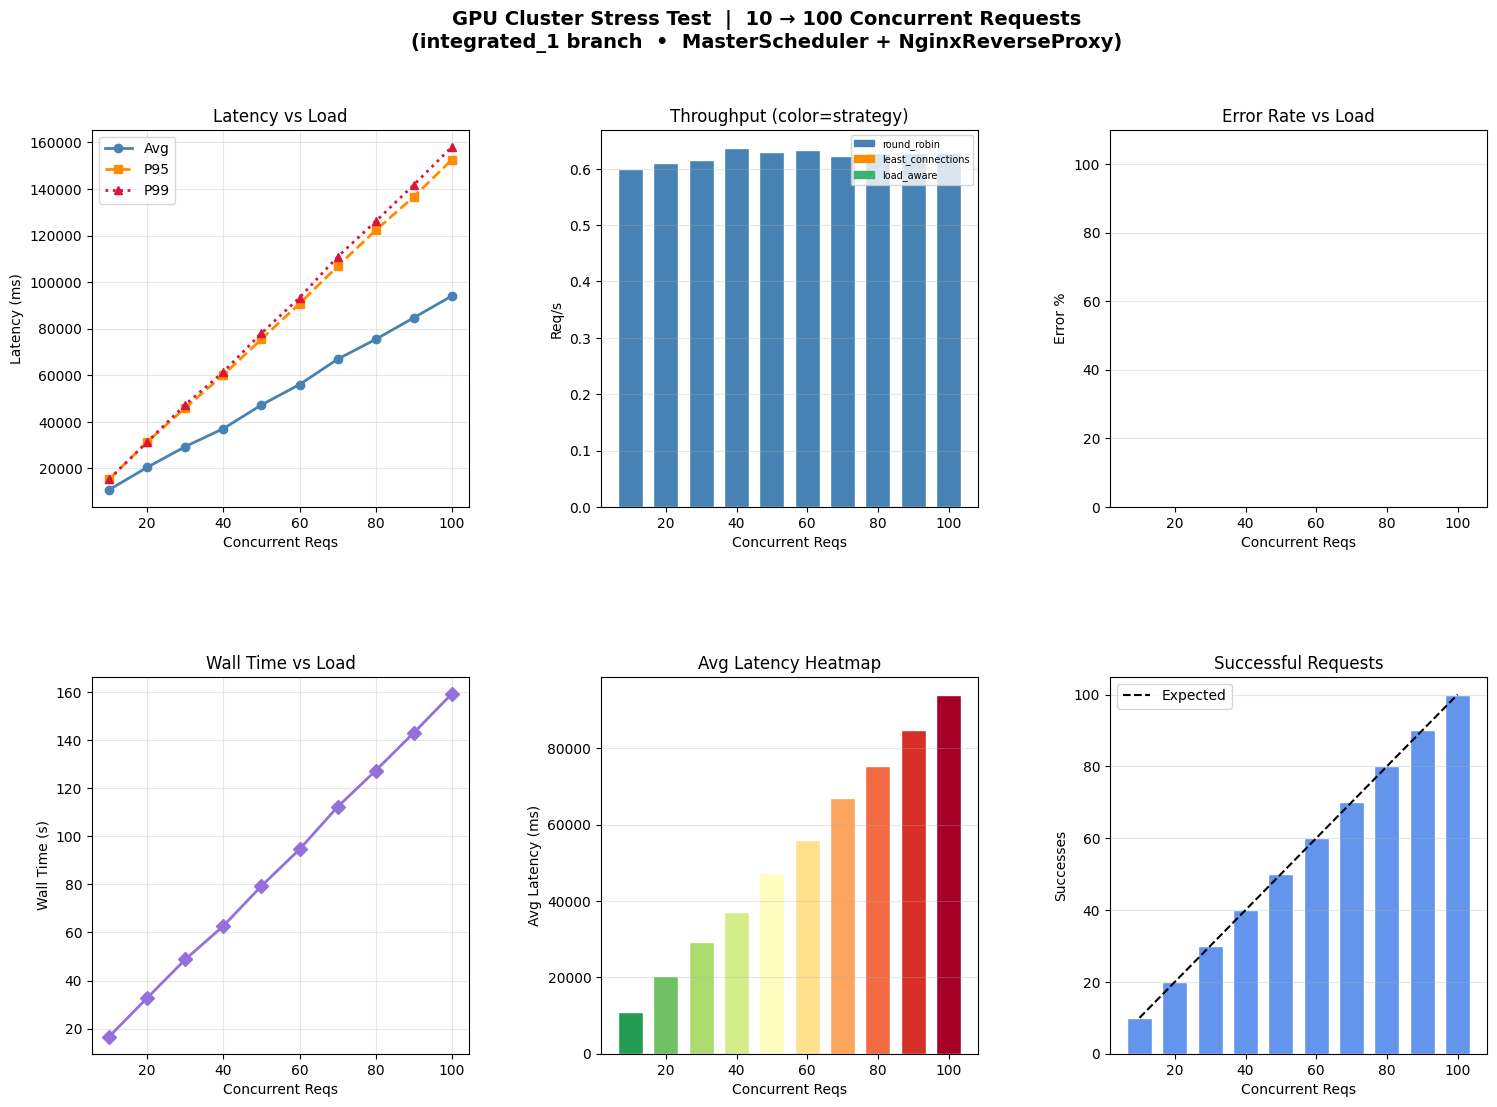


✅ Saved: stress_test_results.png


In [54]:
# ── CELL: Build shared RAG index ONCE ──────────────────────
import aiohttp, asyncio, nest_asyncio
nest_asyncio.apply()

from Rag.retriever import RAGRetriever

DOCS = [
    "Paris is the capital of France. It is known for the Eiffel Tower.",
    "Cairo is the capital of Egypt. It lies on the Nile River.",
    "Neural networks are inspired by the human brain and learn from data.",
    "FAISS is a library by Meta for fast similarity search of dense vectors.",
    "The T4 GPU by NVIDIA is used for machine learning inference in the cloud.",
    "GPU clusters distribute heavy inference tasks across multiple workers.",
    "RAG augments LLM prompts with retrieved context chunks from a knowledge base.",
    "Round robin load balancing cycles requests evenly across all workers.",
    "Least connections routing sends new requests to the least busy worker.",
    "Load-aware routing scores CPU, RAM, and active tasks to pick the best worker.",
]

async def build_shared_retriever():
    retriever = RAGRetriever()
    async with aiohttp.ClientSession() as session:
        await retriever.build_index(session, DOCS)
    return retriever

shared_retriever = asyncio.run(build_shared_retriever())
print(f"✅ RAG index ready — {shared_retriever.index.ntotal} vectors stored")
# ============================================================
# STRESS TEST — integrated_1 branch architecture
# Load: 10, 20, 30 ... 100 concurrent requests
# ============================================================
import asyncio
import time
import statistics
import uuid
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys, os, nest_asyncio

nest_asyncio.apply()  # allow asyncio in Colab

BASE = '/content/drive/MyDrive/Rag_Distributed_testing/integrated'
sys.path.insert(0, BASE)
os.chdir(BASE)

from master.scheduler import GPUWorker, MasterScheduler
from lb.nginx_proxy import NginxReverseProxy
from common.models import InferenceRequest

# ─── CONFIG ──────────────────────────────────────────────────
NUM_WORKERS  = 4
WORKER_CAP   = 50          # tasks per worker before "overloaded"
LOAD_LEVELS  = list(range(10, 101, 10))   # [10,20,...,100]
TEST_PROMPT  = "What is GPU cluster task distribution?"
# ─────────────────────────────────────────────────────────────

async def run_stress_level(num_users: int):
    """Spin up a fresh scheduler + proxy, fire num_users concurrent requests."""
    workers   = [GPUWorker(worker_id=f"gpu-{i}", capacity=WORKER_CAP) for i in range(NUM_WORKERS)]
    proxy     = NginxReverseProxy()
    scheduler = MasterScheduler(workers=workers, proxy=proxy)
    scheduler.start()

    decision = scheduler.prepare_for_traffic(expected_users=num_users)
    print(f"  📋 Strategy chosen: {decision.selected_strategy}  ({decision.reason})")

    async def one_request(uid: int):
        req = InferenceRequest(
            request_id=str(uuid.uuid4()),
            user_id=uid,
            prompt=TEST_PROMPT,
        )
        resp = await scheduler.submit_request(req)
        return resp

    wall_start = time.perf_counter()
    responses  = await asyncio.gather(*[one_request(i) for i in range(num_users)])
    wall_time  = time.perf_counter() - wall_start

    await scheduler.stop()

    latencies  = [r.latency_ms for r in responses if r.success]
    errors     = [r for r in responses if not r.success]

    return latencies, errors, wall_time, decision.selected_strategy


# ─── RUN ALL LOAD LEVELS ─────────────────────────────────────
results = {}

async def run_all():
    for load in LOAD_LEVELS:
        print(f"\n🔥 Load Level: {load} requests")
        latencies, errors, wall_time, strategy = await run_stress_level(load)

        if latencies:
            avg_lat    = statistics.mean(latencies)
            p95_lat    = sorted(latencies)[max(0, int(0.95 * len(latencies)) - 1)]
            p99_lat    = sorted(latencies)[max(0, int(0.99 * len(latencies)) - 1)]
            throughput = len(latencies) / wall_time
        else:
            avg_lat = p95_lat = p99_lat = throughput = 0.0

        error_rate = len(errors) / load * 100

        results[load] = dict(
            avg_latency=avg_lat, p95_latency=p95_lat, p99_latency=p99_lat,
            throughput=throughput, error_rate=error_rate,
            wall_time=wall_time, success_count=len(latencies),
            strategy=strategy,
        )
        print(f"  ✅ {len(latencies)}/{load} ok | ❌ {len(errors)} errors | Strategy: {strategy}")
        print(f"  ⏱  Avg: {avg_lat:.1f}ms | P95: {p95_lat:.1f}ms | P99: {p99_lat:.1f}ms")
        print(f"  🚀 Throughput: {throughput:.1f} req/s | Wall: {wall_time:.2f}s")

asyncio.run(run_all())


# ─── PLOT ─────────────────────────────────────────────────────
loads       = list(results.keys())
avg_lats    = [results[l]["avg_latency"]   for l in loads]
p95_lats    = [results[l]["p95_latency"]   for l in loads]
p99_lats    = [results[l]["p99_latency"]   for l in loads]
throughputs = [results[l]["throughput"]    for l in loads]
error_rates = [results[l]["error_rate"]    for l in loads]
wall_times  = [results[l]["wall_time"]     for l in loads]
successes   = [results[l]["success_count"] for l in loads]
strategies  = [results[l]["strategy"]      for l in loads]

# Color-code bars by strategy switch
strat_colors = {"round_robin": "steelblue", "least_connections": "darkorange", "load_aware": "mediumseagreen"}
bar_colors = [strat_colors.get(s, "gray") for s in strategies]

fig = plt.figure(figsize=(18, 12))
fig.suptitle("GPU Cluster Stress Test  |  10 → 100 Concurrent Requests\n(integrated_1 branch  •  MasterScheduler + NginxReverseProxy)",
             fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1 — Latency curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(loads, avg_lats, 'o-',  label='Avg',  color='steelblue',  lw=2)
ax1.plot(loads, p95_lats, 's--', label='P95',  color='darkorange', lw=2)
ax1.plot(loads, p99_lats, '^:',  label='P99',  color='crimson',    lw=2)
ax1.set_title("Latency vs Load"); ax1.set_xlabel("Concurrent Reqs"); ax1.set_ylabel("Latency (ms)")
ax1.legend(); ax1.grid(True, alpha=0.3)

# 2 — Throughput
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(loads, throughputs, color=bar_colors, edgecolor='white', width=7)
ax2.set_title("Throughput (color=strategy)"); ax2.set_xlabel("Concurrent Reqs"); ax2.set_ylabel("Req/s")
ax2.grid(True, alpha=0.3, axis='y')
from matplotlib.patches import Patch
legend_els = [Patch(color=v, label=k) for k, v in strat_colors.items()]
ax2.legend(handles=legend_els, fontsize=7)

# 3 — Error Rate
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(loads, error_rates, color='tomato', edgecolor='white', width=7)
ax3.set_title("Error Rate vs Load"); ax3.set_xlabel("Concurrent Reqs"); ax3.set_ylabel("Error %")
ax3.set_ylim(0, 110); ax3.grid(True, alpha=0.3, axis='y')

# 4 — Wall Time
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(loads, wall_times, 'D-', color='mediumpurple', lw=2, markersize=7)
ax4.set_title("Wall Time vs Load"); ax4.set_xlabel("Concurrent Reqs"); ax4.set_ylabel("Wall Time (s)")
ax4.grid(True, alpha=0.3)

# 5 — Avg Latency heatmap bar
ax5 = fig.add_subplot(gs[1, 1])
norm_lats = [v / max(avg_lats or [1]) for v in avg_lats]
colors5 = plt.cm.RdYlGn_r(norm_lats)
ax5.bar(loads, avg_lats, color=colors5, edgecolor='white', width=7)
ax5.set_title("Avg Latency Heatmap"); ax5.set_xlabel("Concurrent Reqs"); ax5.set_ylabel("Avg Latency (ms)")
ax5.grid(True, alpha=0.3, axis='y')

# 6 — Success count
ax6 = fig.add_subplot(gs[1, 2])
ax6.bar(loads, successes, color='cornflowerblue', edgecolor='white', width=7)
ax6.plot(loads, loads, 'k--', label='Expected', lw=1.5)
ax6.set_title("Successful Requests"); ax6.set_xlabel("Concurrent Reqs"); ax6.set_ylabel("Successes")
ax6.legend(); ax6.grid(True, alpha=0.3, axis='y')

plt.savefig("stress_test_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Saved: stress_test_results.png")

🔥 Running 40 concurrent requests | Strategy: round_robin

  Total: 40 | ✅ 40 | ❌ 0
  Avg Latency: 40551.9ms | Throughput: 0.60 req/s
  Error Rate: 0.0%

  Per-Worker Requests Handled:
    gpu-0: 10 requests
    gpu-1: 10 requests
    gpu-2: 10 requests
    gpu-3: 10 requests

  Worker Health Snapshots:
    gpu-0: ✅ UP | RAM 31.6% | processed=10 | failed=0
    gpu-1: ✅ UP | RAM 26.0% | processed=10 | failed=0
    gpu-2: ✅ UP | RAM 29.2% | processed=10 | failed=0
    gpu-3: ✅ UP | RAM 28.7% | processed=10 | failed=0


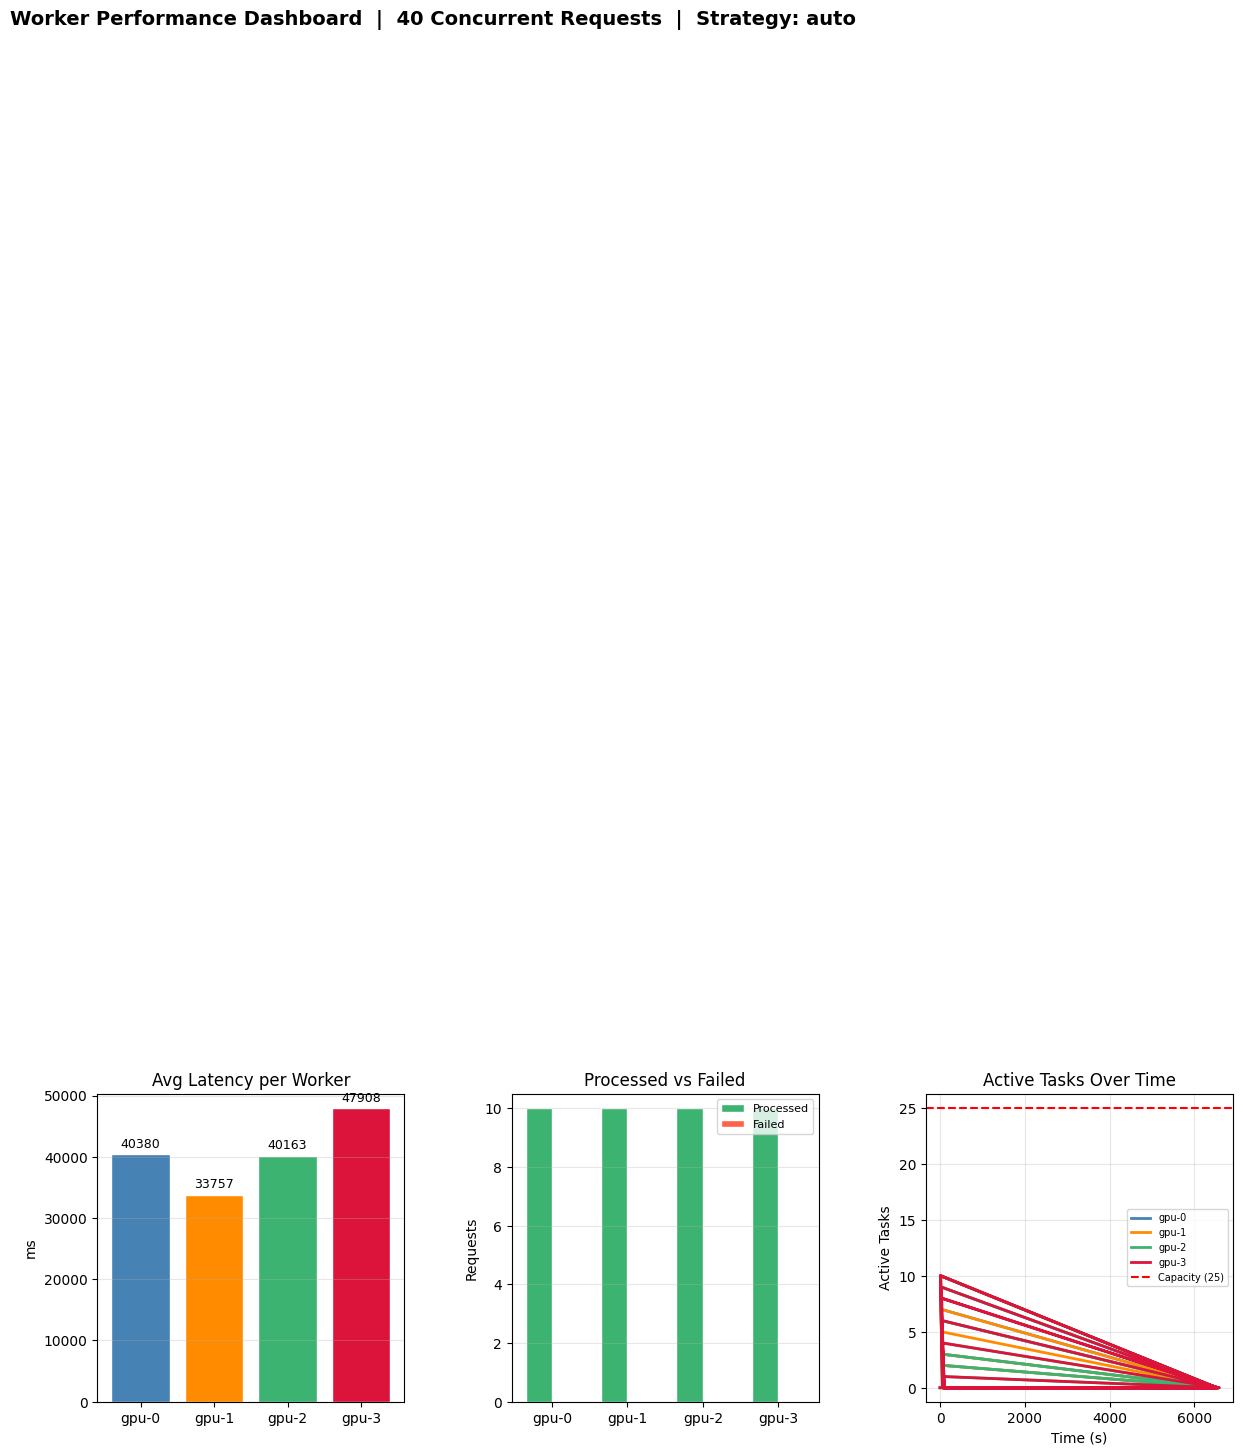


✅ Saved: worker_performance_dashboard.png


In [58]:
# ══════════════════════════════════════════════════════════════
# WORKER PERFORMANCE METRICS CELL
# Runs ONE load level (configurable), collects per-worker stats
# at runtime + plots full dashboard
# ══════════════════════════════════════════════════════════════
import asyncio, uuid, time, statistics, nest_asyncio
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
nest_asyncio.apply()

import sys, os
sys.path.insert(0, '/content/drive/MyDrive/Rag_Distributed_testing/integrated')
os.chdir('/content/drive/MyDrive/Rag_Distributed_testing/integrated')

from master.scheduler import GPUWorker, MasterScheduler
from lb.nginx_proxy import NginxReverseProxy
from common.models import InferenceRequest
from metrics import MetricsCollector

# ─── CONFIG ──────────────────────────────────────────────────
NUM_WORKERS   = 4
WORKER_CAP    = 25
TEST_LOAD     = 40          # ← change this to test different levels
TEST_PROMPT   = "What is GPU cluster task distribution?"
SAMPLE_EVERY = 8   # one snapshot every 2 seconds
# ─────────────────────────────────────────────────────────────

# Per-worker time-series snapshots (sampled during the run)
worker_timeline = {f"gpu-{i}": {"ram": [], "active": [], "t": []} for i in range(NUM_WORKERS)}
per_worker_latencies = {f"gpu-{i}": [] for i in range(NUM_WORKERS)}

async def worker_monitor(workers, stop_event):
    """Sample worker stats every SAMPLE_EVERY seconds."""
    t0 = time.perf_counter()
    while not stop_event.is_set():
        t = time.perf_counter() - t0
        for w in workers:
            wid = w.id
            worker_timeline[wid]["t"].append(t)
            worker_timeline[wid]["ram"].append(w.get_ram_utilization() * 100)
            worker_timeline[wid]["active"].append(w.active_tasks)
        await asyncio.sleep(SAMPLE_EVERY)

async def run_worker_metrics_test():
    workers   = [GPUWorker(worker_id=f"gpu-{i}", capacity=WORKER_CAP) for i in range(NUM_WORKERS)]

    # Inject shared RAG retriever
    for w in workers:
        w._retriever = shared_retriever   # built in the RAG cell above

    proxy     = NginxReverseProxy()
    scheduler = MasterScheduler(workers=workers, proxy=proxy)
    scheduler.start()
    decision  = scheduler.prepare_for_traffic(expected_users=TEST_LOAD)
    metrics   = MetricsCollector()

    print(f"🔥 Running {TEST_LOAD} concurrent requests | Strategy: {decision.selected_strategy}")

    stop_event = asyncio.Event()
    monitor_task = asyncio.create_task(worker_monitor(workers, stop_event))

    import aiohttp
    async with aiohttp.ClientSession() as session:
        # Attach session to workers
        for w in workers:
            w._session = session

        async def one_req(uid):
            req  = InferenceRequest(request_id=str(uuid.uuid4()), user_id=uid, prompt=TEST_PROMPT)
            resp = await scheduler.submit_request(req)
            metrics.record(resp)
            if resp.success and resp.worker_id:
                per_worker_latencies[resp.worker_id].append(resp.latency_ms)
            return resp

        await asyncio.gather(*[one_req(i) for i in range(TEST_LOAD)])

    stop_event.set()
    await monitor_task
    await scheduler.stop()

    summary   = metrics.summary(scheduler.worker_snapshots())
    snapshots = summary["worker_snapshots"]
    return summary, snapshots

summary, snapshots = asyncio.run(run_worker_metrics_test())

# ─── PRINT TEXT SUMMARY ──────────────────────────────────────
print(f"\n{'='*70}")
print(f"  Total: {summary['total_requests']} | ✅ {summary['successful_requests']} | ❌ {summary['failed_requests']}")
print(f"  Avg Latency: {summary['avg_latency_ms']:.1f}ms | Throughput: {summary['throughput_rps']:.2f} req/s")
print(f"  Error Rate: {summary['error_rate_percent']:.1f}%")
print(f"\n  Per-Worker Requests Handled:")
for wid, count in sorted(summary["requests_per_worker"].items()):
    print(f"    {wid}: {count} requests")
print(f"\n  Worker Health Snapshots:")
for w in snapshots:
    status = "✅ UP" if w.is_alive else "❌ DOWN"
    print(f"    {w.worker_id}: {status} | RAM {w.ram_utilization*100:.1f}% "
          f"| processed={w.processed_requests} | failed={w.failed_requests}")
print(f"{'='*70}")

# ─── PLOT WORKER DASHBOARD ────────────────────────────────────
worker_ids = [f"gpu-{i}" for i in range(NUM_WORKERS)]
colors     = ["steelblue", "darkorange", "mediumseagreen", "crimson"]

fig = plt.figure(figsize=(20, 16))
fig.suptitle(f"Worker Performance Dashboard  |  {TEST_LOAD} Concurrent Requests  |  Strategy: {summary.get('strategy', 'auto')}",
             fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.35)



# Row 3 col 1 — Avg latency per worker (bar)
ax_lat = fig.add_subplot(gs[2, 1])
avg_lats_per_worker = [
    statistics.mean(per_worker_latencies[wid]) if per_worker_latencies[wid] else 0
    for wid in worker_ids
]
bars2 = ax_lat.bar(worker_ids, avg_lats_per_worker, color=colors, edgecolor='white')
ax_lat.bar_label(bars2, fmt='%.0f', padding=3, fontsize=9)
ax_lat.set_title("Avg Latency per Worker"); ax_lat.set_ylabel("ms")
ax_lat.grid(True, alpha=0.3, axis='y')

# Row 3 col 2 — Processed vs Failed per worker
ax_pf = fig.add_subplot(gs[2, 2])
x      = np.arange(NUM_WORKERS)
width  = 0.35
proc   = [s.processed_requests for s in snapshots]
fail   = [s.failed_requests     for s in snapshots]
ax_pf.bar(x - width/2, proc, width, label='Processed', color='mediumseagreen', edgecolor='white')
ax_pf.bar(x + width/2, fail, width, label='Failed',    color='tomato',         edgecolor='white')
ax_pf.set_xticks(x); ax_pf.set_xticklabels(worker_ids)
ax_pf.set_title("Processed vs Failed"); ax_pf.set_ylabel("Requests")
ax_pf.legend(fontsize=8); ax_pf.grid(True, alpha=0.3, axis='y')

# Row 3 col 3 — Active tasks over time (all workers on one chart)
ax_act = fig.add_subplot(gs[2, 3])
for i, wid in enumerate(worker_ids):
    tl = worker_timeline[wid]
    ax_act.plot(tl["t"], tl["active"], color=colors[i], lw=2, label=wid)
ax_act.axhline(WORKER_CAP, color='red', lw=1.5, linestyle='--', label=f'Capacity ({WORKER_CAP})')
ax_act.set_title("Active Tasks Over Time"); ax_act.set_xlabel("Time (s)"); ax_act.set_ylabel("Active Tasks")
ax_act.legend(fontsize=7); ax_act.grid(True, alpha=0.3)

plt.savefig("worker_performance_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Saved: worker_performance_dashboard.png")

🔥 Running 40 concurrent requests | Strategy: load_aware

  Total: 40 | ✅ 40 | ❌ 0
  Avg Latency: 36469.3ms | Throughput: 0.64 req/s
  Error Rate: 0.0%

  Per-Worker Requests Handled:
    gpu-0: 10 requests
    gpu-1: 10 requests
    gpu-2: 10 requests
    gpu-3: 10 requests

  Worker Health Snapshots:
    gpu-0: ✅ UP | RAM 27.4% | processed=10 | failed=0
    gpu-1: ✅ UP | RAM 26.1% | processed=10 | failed=0
    gpu-2: ✅ UP | RAM 28.8% | processed=10 | failed=0
    gpu-3: ✅ UP | RAM 30.5% | processed=10 | failed=0


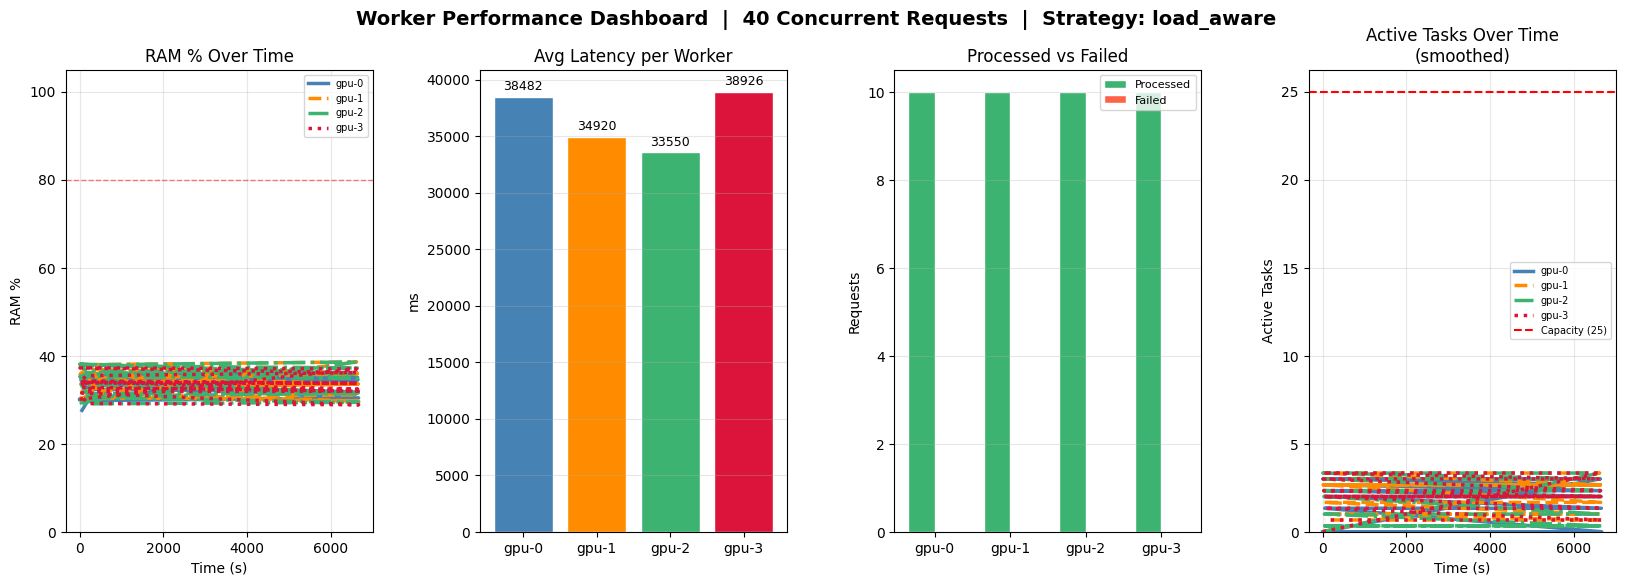


✅ Saved: worker_performance_dashboard.png


In [59]:
# ══════════════════════════════════════════════════════════════
# WORKER PERFORMANCE METRICS CELL
# ══════════════════════════════════════════════════════════════
import asyncio, uuid, time, statistics, nest_asyncio
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
nest_asyncio.apply()

import sys, os
sys.path.insert(0, '/content/drive/MyDrive/Rag_Distributed_testing/integrated')
os.chdir('/content/drive/MyDrive/Rag_Distributed_testing/integrated')

from master.scheduler import GPUWorker, MasterScheduler
from lb.nginx_proxy import NginxReverseProxy
from common.models import InferenceRequest
from metrics import MetricsCollector

# ─── CONFIG ──────────────────────────────────────────────────
NUM_WORKERS   = 4
WORKER_CAP    = 25
TEST_LOAD     = 40
TEST_PROMPT   = "What is GPU cluster task distribution?"
SAMPLE_EVERY  = 8    # ✅ Fix 2: was 20 (seconds not ms — too slow to catch anything)
# ─────────────────────────────────────────────────────────────

worker_timeline      = {f"gpu-{i}": {"ram": [], "active": [], "t": []} for i in range(NUM_WORKERS)}
per_worker_latencies = {f"gpu-{i}": [] for i in range(NUM_WORKERS)}

async def worker_monitor(workers, stop_event):
    t0 = time.perf_counter()
    while not stop_event.is_set():
        t = time.perf_counter() - t0
        for w in workers:
            wid = w.id
            worker_timeline[wid]["t"].append(t)
            worker_timeline[wid]["ram"].append(w.get_ram_utilization() * 100)
            worker_timeline[wid]["active"].append(w.active_tasks)
        await asyncio.sleep(SAMPLE_EVERY)

async def run_worker_metrics_test():
    workers  = [GPUWorker(worker_id=f"gpu-{i}", capacity=WORKER_CAP) for i in range(NUM_WORKERS)]
    for w in workers:
        w._retriever = shared_retriever

    proxy    = NginxReverseProxy()
    # ✅ Fix 3: force load_aware strategy directly
    scheduler = MasterScheduler(workers=workers, proxy=proxy, scheduling_policy="load_aware")
    scheduler.start()
    decision  = scheduler.prepare_for_traffic(expected_users=TEST_LOAD)
    metrics   = MetricsCollector()

    print(f"🔥 Running {TEST_LOAD} concurrent requests | Strategy: {decision.selected_strategy}")

    stop_event   = asyncio.Event()
    monitor_task = asyncio.create_task(worker_monitor(workers, stop_event))

    import aiohttp
    async with aiohttp.ClientSession() as session:
        for w in workers:
            w._session = session

        async def one_req(uid):
            req  = InferenceRequest(request_id=str(uuid.uuid4()), user_id=uid, prompt=TEST_PROMPT)
            resp = await scheduler.submit_request(req)
            metrics.record(resp)
            if resp.success and resp.worker_id:
                per_worker_latencies[resp.worker_id].append(resp.latency_ms)
            return resp

        await asyncio.gather(*[one_req(i) for i in range(TEST_LOAD)])

    stop_event.set()
    await monitor_task
    await scheduler.stop()

    summary   = metrics.summary(scheduler.worker_snapshots())
    snapshots = summary["worker_snapshots"]
    return summary, snapshots, decision

summary, snapshots, decision = asyncio.run(run_worker_metrics_test())

# ─── PRINT TEXT SUMMARY ──────────────────────────────────────
print(f"\n{'='*70}")
print(f"  Total: {summary['total_requests']} | ✅ {summary['successful_requests']} | ❌ {summary['failed_requests']}")
print(f"  Avg Latency: {summary['avg_latency_ms']:.1f}ms | Throughput: {summary['throughput_rps']:.2f} req/s")
print(f"  Error Rate: {summary['error_rate_percent']:.1f}%")
print(f"\n  Per-Worker Requests Handled:")
for wid, count in sorted(summary["requests_per_worker"].items()):
    print(f"    {wid}: {count} requests")
print(f"\n  Worker Health Snapshots:")
for w in snapshots:
    status = "✅ UP" if w.is_alive else "❌ DOWN"
    print(f"    {w.worker_id}: {status} | RAM {w.ram_utilization*100:.1f}% "
          f"| processed={w.processed_requests} | failed={w.failed_requests}")
print(f"{'='*70}")

# ─── PLOT WORKER DASHBOARD ────────────────────────────────────
worker_ids  = [f"gpu-{i}" for i in range(NUM_WORKERS)]
colors      = ["steelblue", "darkorange", "mediumseagreen", "crimson"]
linestyles  = ['-', '--', '-.', ':']

def smooth(values, window=3):
    if len(values) < window:
        return values
    return list(np.convolve(values, np.ones(window)/window, mode='valid'))

fig = plt.figure(figsize=(20, 6))
# ✅ Fix 4: GridSpec(1,4) — only 1 row of plots, no empty rows
fig.suptitle(
    f"Worker Performance Dashboard  |  {TEST_LOAD} Concurrent Requests  |  Strategy: {decision.selected_strategy}",
    fontsize=14, fontweight='bold'
)
gs = gridspec.GridSpec(1, 4, figure=fig, hspace=0.5, wspace=0.35)

# Col 0 — RAM % over time
ax_ram = fig.add_subplot(gs[0, 0])
for i, wid in enumerate(worker_ids):
    tl = worker_timeline[wid]
    if not tl["t"]: continue
    y = smooth(tl["ram"])
    ax_ram.plot(tl["t"][:len(y)], y, color=colors[i], lw=2.5,
                linestyle=linestyles[i], label=wid)
ax_ram.axhline(80, color='red', lw=1, linestyle='--', alpha=0.5)
ax_ram.set_title("RAM % Over Time"); ax_ram.set_xlabel("Time (s)"); ax_ram.set_ylabel("RAM %")
ax_ram.set_ylim(0, 105); ax_ram.legend(fontsize=7); ax_ram.grid(True, alpha=0.3)

# Col 1 — Avg latency per worker
ax_lat = fig.add_subplot(gs[0, 1])
avg_lats = [statistics.mean(per_worker_latencies[wid]) if per_worker_latencies[wid] else 0 for wid in worker_ids]
bars = ax_lat.bar(worker_ids, avg_lats, color=colors, edgecolor='white')
ax_lat.bar_label(bars, fmt='%.0f', padding=3, fontsize=9)
ax_lat.set_title("Avg Latency per Worker"); ax_lat.set_ylabel("ms")
ax_lat.grid(True, alpha=0.3, axis='y')

# Col 2 — Processed vs Failed
ax_pf  = fig.add_subplot(gs[0, 2])
x      = np.arange(NUM_WORKERS)
width  = 0.35
proc   = [s.processed_requests for s in snapshots]
fail   = [s.failed_requests     for s in snapshots]
ax_pf.bar(x - width/2, proc, width, label='Processed', color='mediumseagreen', edgecolor='white')
ax_pf.bar(x + width/2, fail, width, label='Failed',    color='tomato',         edgecolor='white')
ax_pf.set_xticks(x); ax_pf.set_xticklabels(worker_ids)
ax_pf.set_title("Processed vs Failed"); ax_pf.set_ylabel("Requests")
ax_pf.legend(fontsize=8); ax_pf.grid(True, alpha=0.3, axis='y')

# Col 3 — Active tasks over time (smoothed + distinct linestyles)
ax_act = fig.add_subplot(gs[0, 3])
for i, wid in enumerate(worker_ids):
    tl = worker_timeline[wid]
    if not tl["t"]: continue
    y = smooth(tl["active"], window=3)
    ax_act.plot(tl["t"][:len(y)], y, color=colors[i], lw=2.5,
                linestyle=linestyles[i], label=wid)
ax_act.axhline(WORKER_CAP, color='red', lw=1.5, linestyle='--', label=f'Capacity ({WORKER_CAP})')
ax_act.set_title("Active Tasks Over Time\n(smoothed)"); ax_act.set_xlabel("Time (s)"); ax_act.set_ylabel("Active Tasks")
ax_act.set_ylim(bottom=0); ax_act.legend(fontsize=7); ax_act.grid(True, alpha=0.3)

plt.savefig("worker_performance_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Saved: worker_performance_dashboard.png")

PHASE 1 — Fault run: gpu-3 killed BEFORE dispatch
          Capacity: 75 slots (3×25) — 25% power removed
  💥 [5.0s] gpu-3 HARD CRASHED — load_aware rerouting all 75 requests to gpu-0/1/2
  ✅ 75/75 ok | ❌ 0 failed
  Avg: 11233.5ms | 0.65 req/s
  Distribution: {'gpu-1': 25, 'gpu-0': 25, 'gpu-2': 25}

PHASE 2 — Normal run (4 workers, full 100-slot capacity)
  ✅ 75/75 ok | Avg: 11102.0ms | 0.69 req/s
  Distribution: {'gpu-0': 19, 'gpu-3': 19, 'gpu-1': 19, 'gpu-2': 18}

FAULT TOLERANCE VERDICT
  gpu-0: ✅ UP | processed=25 | failed=0
  gpu-1: ✅ UP | processed=25 | failed=0
  gpu-2: ✅ UP | processed=25 | failed=0
  gpu-3: ❌ DOWN | processed=0 | failed=0

  Capacity after failure   : 75% (3/4 workers × 25 slots)
  Requests redistributed   : 75 handled by surviving workers
  Latency impact           : +131.6ms vs normal
  Throughput impact        : -0.04 req/s vs normal
  System survived          : ✅ YES


/tmp/ipykernel_3058/2050735429.py:283: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("fault_tolerance_test.png", dpi=150, bbox_inches='tight')
/tmp/ipykernel_3058/2050735429.py:283: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("fault_tolerance_test.png", dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


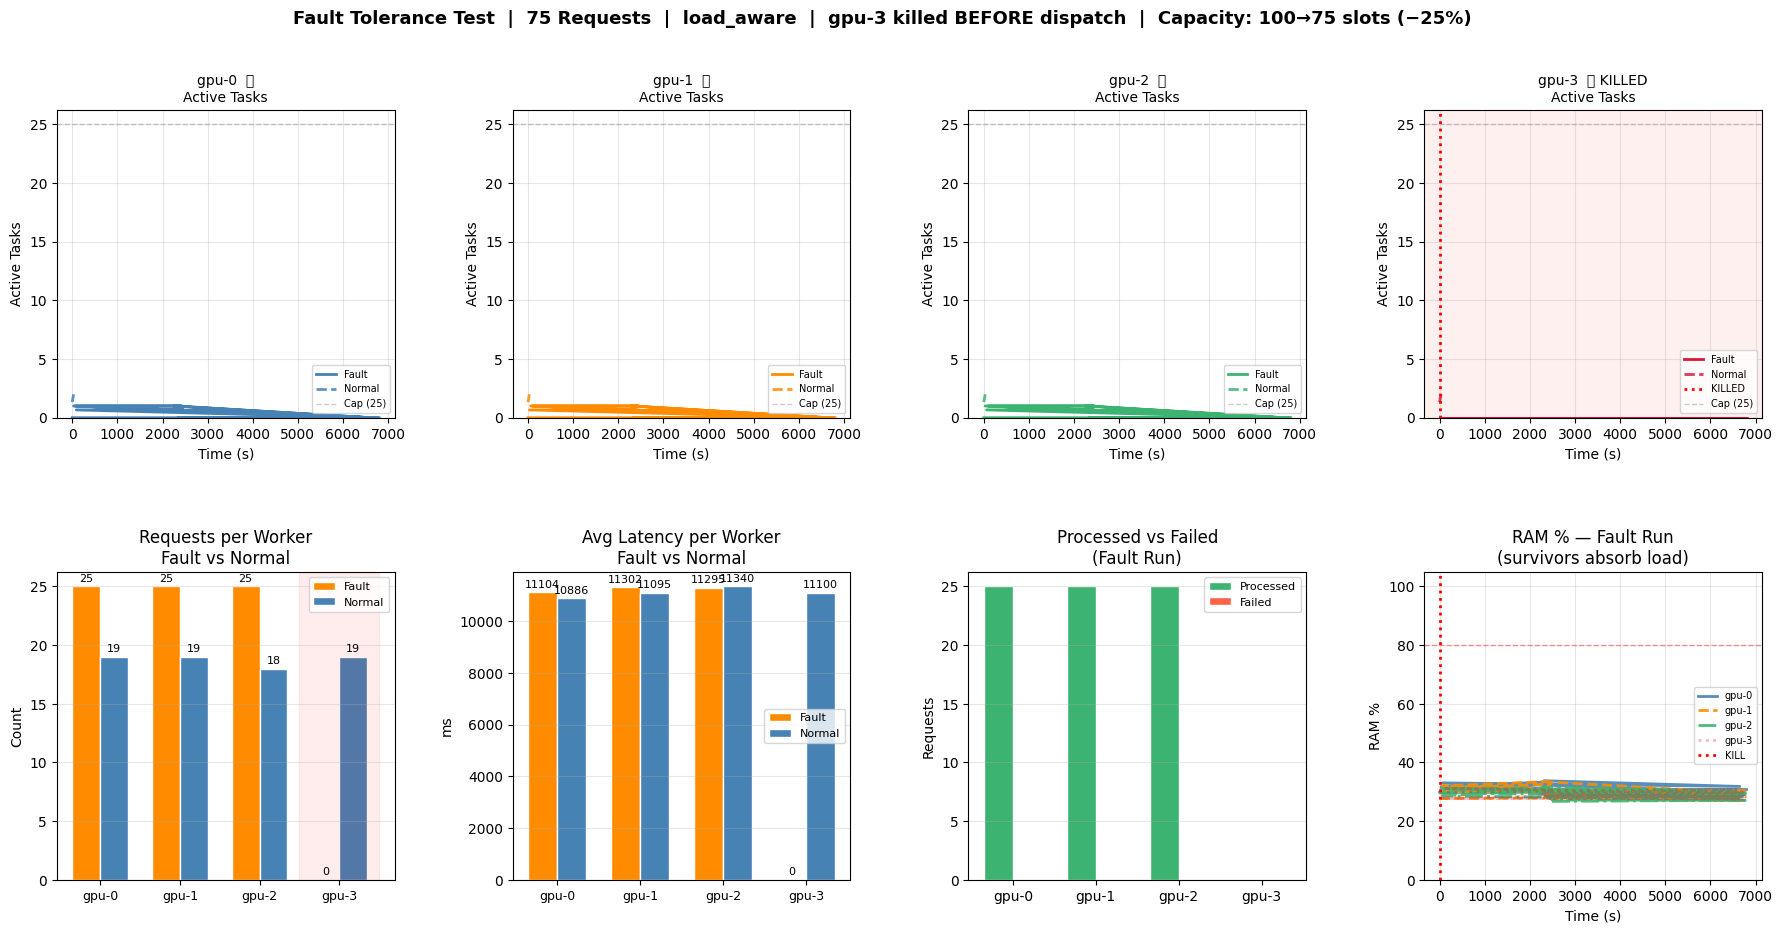


✅ Saved: fault_tolerance_test.png


In [74]:
# ══════════════════════════════════════════════════════════════
# FAULT TOLERANCE TEST
# ══════════════════════════════════════════════════════════════
import asyncio, uuid, time, statistics, nest_asyncio
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
nest_asyncio.apply()

import sys, os
sys.path.insert(0, '/content/drive/MyDrive/Rag_Distributed_testing/integrated')
os.chdir('/content/drive/MyDrive/Rag_Distributed_testing/integrated')

from master.scheduler import GPUWorker, MasterScheduler
from lb.nginx_proxy import NginxReverseProxy
from common.models import InferenceRequest
from metrics import MetricsCollector

# ─── CONFIG ──────────────────────────────────────────────────
NUM_WORKERS      = 4
WORKER_CAP       = 25
FAILED_WORKER_ID = "gpu-3"
TEST_LOAD        = 75
TEST_PROMPT      = "What is GPU cluster task distribution?"
SAMPLE_EVERY     = 30
FAIL_AFTER_SECS  = 5
MAX_CONCURRENT   = 8
# ─────────────────────────────────────────────────────────────

def fresh_timeline(wids):
    return {wid: {"ram": [], "active": [], "t": [], "alive": []} for wid in wids}

def smooth(values, window=3):
    if len(values) < window:
        return values
    return list(np.convolve(values, np.ones(window) / window, mode='valid'))

worker_ids = [f"gpu-{i}" for i in range(NUM_WORKERS)]
colors     = ["steelblue", "darkorange", "mediumseagreen", "crimson"]
linestyles = ['-', '--', '-.', ':']

# ══════════════════════════════════════════════════════════════
# PHASE 1 — Fault: gpu-3 killed BEFORE dispatch
# ══════════════════════════════════════════════════════════════
print("=" * 65)
print(f"PHASE 1 — Fault run: {FAILED_WORKER_ID} killed BEFORE dispatch")
print(f"          Capacity: 75 slots (3×25) — 25% power removed")
print("=" * 65)

tl_fault  = fresh_timeline(worker_ids)
lat_fault = {wid: [] for wid in worker_ids}
fail_time = [None]

async def run_fault():
    workers = [GPUWorker(worker_id=wid, capacity=WORKER_CAP) for wid in worker_ids]
    for w in workers:
        w._retriever = shared_retriever
    proxy   = NginxReverseProxy()
    sched   = MasterScheduler(workers=workers, proxy=proxy, scheduling_policy="load_aware")
    sched.start()
    dec     = sched.prepare_for_traffic(expected_users=TEST_LOAD)
    metrics = MetricsCollector()
    stop_ev = asyncio.Event()
    t_start = time.perf_counter()

    async def monitor():
        while not stop_ev.is_set():
            t = time.perf_counter() - t_start
            for w in workers:
                tl_fault[w.id]["t"].append(t)
                tl_fault[w.id]["ram"].append(w.get_ram_utilization() * 100)
                tl_fault[w.id]["active"].append(w.active_tasks)
                tl_fault[w.id]["alive"].append(w.is_alive)
            await asyncio.sleep(SAMPLE_EVERY)

    import aiohttp
    async with aiohttp.ClientSession() as session:
        for w in workers: w._session = session
        mon = asyncio.create_task(monitor())

        await asyncio.sleep(FAIL_AFTER_SECS)
        sched.simulate_worker_failure(FAILED_WORKER_ID)
        fail_time[0] = time.perf_counter() - t_start
        dead_worker  = sched._find_worker(FAILED_WORKER_ID)
        if dead_worker:
            dead_worker.active_tasks = 0
            print(f"  💥 [{fail_time[0]:.1f}s] {FAILED_WORKER_ID} HARD CRASHED — "
                  f"load_aware rerouting all {TEST_LOAD} requests to gpu-0/1/2")
        else:
            print(f"  💥 [{fail_time[0]:.1f}s] {FAILED_WORKER_ID} FAILED")

        dispatch_sem = asyncio.Semaphore(MAX_CONCURRENT)

        async def one_req(uid):
            async with dispatch_sem:
                req  = InferenceRequest(request_id=str(uuid.uuid4()), user_id=uid, prompt=TEST_PROMPT)
                resp = await sched.submit_request(req)
                metrics.record(resp)
                if resp.success and resp.worker_id:
                    lat_fault[resp.worker_id].append(resp.latency_ms)

        await asyncio.gather(*[one_req(i) for i in range(TEST_LOAD)])

    stop_ev.set(); await mon; await sched.stop()
    return metrics.summary(sched.worker_snapshots()), dec

sum_fault, dec_fault = asyncio.run(run_fault())
snap_fault = sum_fault["worker_snapshots"]

print(f"  ✅ {sum_fault['successful_requests']}/{sum_fault['total_requests']} ok"
      f" | ❌ {sum_fault['failed_requests']} failed")
print(f"  Avg: {sum_fault['avg_latency_ms']:.1f}ms | {sum_fault['throughput_rps']:.2f} req/s")
print(f"  Distribution: {sum_fault['requests_per_worker']}")

# ══════════════════════════════════════════════════════════════
# PHASE 2 — Normal: all 4 workers healthy
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("PHASE 2 — Normal run (4 workers, full 100-slot capacity)")
print("=" * 65)

tl_normal  = fresh_timeline(worker_ids)
lat_normal = {wid: [] for wid in worker_ids}

async def run_normal():
    workers = [GPUWorker(worker_id=wid, capacity=WORKER_CAP) for wid in worker_ids]
    for w in workers:
        w._retriever = shared_retriever
    proxy   = NginxReverseProxy()
    sched   = MasterScheduler(workers=workers, proxy=proxy, scheduling_policy="load_aware")
    sched.start()
    dec     = sched.prepare_for_traffic(expected_users=TEST_LOAD)
    metrics = MetricsCollector()
    stop_ev = asyncio.Event()

    async def monitor():
        t0 = time.perf_counter()
        while not stop_ev.is_set():
            t = time.perf_counter() - t0
            for w in workers:
                tl_normal[w.id]["t"].append(t)
                tl_normal[w.id]["ram"].append(w.get_ram_utilization() * 100)
                tl_normal[w.id]["active"].append(w.active_tasks)
                tl_normal[w.id]["alive"].append(w.is_alive)
            await asyncio.sleep(SAMPLE_EVERY)

    import aiohttp
    async with aiohttp.ClientSession() as session:
        for w in workers: w._session = session
        mon          = asyncio.create_task(monitor())
        dispatch_sem = asyncio.Semaphore(MAX_CONCURRENT)

        async def one_req(uid):
            async with dispatch_sem:
                req  = InferenceRequest(request_id=str(uuid.uuid4()), user_id=uid, prompt=TEST_PROMPT)
                resp = await sched.submit_request(req)
                metrics.record(resp)
                if resp.success and resp.worker_id:
                    lat_normal[resp.worker_id].append(resp.latency_ms)

        await asyncio.gather(*[one_req(i) for i in range(TEST_LOAD)])

    stop_ev.set(); await mon; await sched.stop()
    return metrics.summary(sched.worker_snapshots()), dec

sum_normal, dec_normal = asyncio.run(run_normal())
print(f"  ✅ {sum_normal['successful_requests']}/{sum_normal['total_requests']} ok"
      f" | Avg: {sum_normal['avg_latency_ms']:.1f}ms"
      f" | {sum_normal['throughput_rps']:.2f} req/s")
print(f"  Distribution: {sum_normal['requests_per_worker']}")

# ── VERDICT ───────────────────────────────────────────────────
print("\n" + "=" * 65)
print("FAULT TOLERANCE VERDICT")
print("=" * 65)
for s in snap_fault:
    status = "✅ UP" if s.is_alive else "❌ DOWN"
    print(f"  {s.worker_id}: {status} | processed={s.processed_requests} | failed={s.failed_requests}")

surviving = sum(sum_fault["requests_per_worker"].get(w, 0) for w in worker_ids if w != FAILED_WORKER_ID)
lat_delta = sum_fault["avg_latency_ms"] - sum_normal["avg_latency_ms"]
thr_delta = sum_fault["throughput_rps"] - sum_normal["throughput_rps"]
print(f"\n  Capacity after failure   : 75% (3/4 workers × 25 slots)")
print(f"  Requests redistributed   : {surviving} handled by surviving workers")
print(f"  Latency impact           : {lat_delta:+.1f}ms vs normal")
print(f"  Throughput impact        : {thr_delta:+.2f} req/s vs normal")
print(f"  System survived          : {'✅ YES' if sum_fault['successful_requests'] > 0 else '❌ NO'}")

# ══════════════════════════════════════════════════════════════
# PLOT
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 10))
fig.suptitle(
    f"Fault Tolerance Test  |  {TEST_LOAD} Requests  |  load_aware  |  "
    f"{FAILED_WORKER_ID} killed BEFORE dispatch  |  Capacity: 100→75 slots (−25%)",
    fontsize=13, fontweight='bold'
)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.35)

# ── Row 0: Active tasks — Fault solid, Normal dashed ──
for i, wid in enumerate(worker_ids):
    ax = fig.add_subplot(gs[0, i])
    tn, tf = tl_normal[wid], tl_fault[wid]

    # Fault = solid (primary)
    if tf["t"]:
        yf = smooth(tf["active"])
        ax.plot(tf["t"][:len(yf)], yf, color=colors[i], lw=2, label="Fault")

    # Normal = dashed (reference)
    if tn["t"]:
        yn = smooth(tn["active"])
        ax.plot(tn["t"][:len(yn)], yn, color=colors[i], lw=2,
                linestyle='--', alpha=0.85, label="Normal")

    if wid == FAILED_WORKER_ID:
        if fail_time[0]:
            ax.axvline(fail_time[0], color='red', lw=2, linestyle=':', label='KILLED')
        ax.set_facecolor('#fff0f0')
        ax.set_title(f"{wid}  ❌ KILLED\nActive Tasks", fontsize=10)
    else:
        ax.set_title(f"{wid}  ✅\nActive Tasks", fontsize=10)

    ax.axhline(WORKER_CAP, color='gray', lw=1, linestyle='--', alpha=0.4, label=f'Cap ({WORKER_CAP})')
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Active Tasks")
    ax.set_ylim(bottom=0); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# ── Row 1 col 0: Requests per worker — Fault first, Normal second ──
ax_rw = fig.add_subplot(gs[1, 0])
xr = np.arange(NUM_WORKERS)
bw = 0.35
fc = [sum_fault["requests_per_worker"].get(wid, 0)  for wid in worker_ids]
nc = [sum_normal["requests_per_worker"].get(wid, 0) for wid in worker_ids]
b1 = ax_rw.bar(xr - bw/2, fc, bw, label="Fault",  color="darkorange", edgecolor='white')
b2 = ax_rw.bar(xr + bw/2, nc, bw, label="Normal", color="steelblue",  edgecolor='white')
ax_rw.bar_label(b1, padding=2, fontsize=8)
ax_rw.bar_label(b2, padding=2, fontsize=8)
ax_rw.set_xticks(xr); ax_rw.set_xticklabels(worker_ids, fontsize=9)
ax_rw.axvspan(NUM_WORKERS - 1.5, NUM_WORKERS - 0.5, alpha=0.07, color='red')
ax_rw.set_title("Requests per Worker\nFault vs Normal")
ax_rw.set_ylabel("Count"); ax_rw.legend(fontsize=8); ax_rw.grid(True, alpha=0.3, axis='y')

# ── Row 1 col 1: Avg latency — Fault first, Normal second ──
ax_lat = fig.add_subplot(gs[1, 1])
fl = [statistics.mean(lat_fault[wid])  if lat_fault[wid]  else 0 for wid in worker_ids]
nl = [statistics.mean(lat_normal[wid]) if lat_normal[wid] else 0 for wid in worker_ids]
b3 = ax_lat.bar(xr - bw/2, fl, bw, label="Fault",  color="darkorange", edgecolor='white')
b4 = ax_lat.bar(xr + bw/2, nl, bw, label="Normal", color="steelblue",  edgecolor='white')
ax_lat.bar_label(b3, fmt='%.0f', padding=2, fontsize=8)
ax_lat.bar_label(b4, fmt='%.0f', padding=2, fontsize=8)
ax_lat.set_xticks(xr); ax_lat.set_xticklabels(worker_ids, fontsize=9)
ax_lat.set_title("Avg Latency per Worker\nFault vs Normal")
ax_lat.set_ylabel("ms"); ax_lat.legend(fontsize=8); ax_lat.grid(True, alpha=0.3, axis='y')

# ── Row 1 col 2: Processed vs Failed (fault run only — unchanged) ──
ax_pf = fig.add_subplot(gs[1, 2])
xp   = np.arange(NUM_WORKERS)
proc = [s.processed_requests for s in snap_fault]
fail = [s.failed_requests     for s in snap_fault]
ax_pf.bar(xp - bw/2, proc, bw, label='Processed', color='mediumseagreen', edgecolor='white')
ax_pf.bar(xp + bw/2, fail, bw, label='Failed',    color='tomato',         edgecolor='white')
ax_pf.set_xticks(xp); ax_pf.set_xticklabels(worker_ids)
ax_pf.set_title("Processed vs Failed\n(Fault Run)")
ax_pf.set_ylabel("Requests"); ax_pf.legend(fontsize=8); ax_pf.grid(True, alpha=0.3, axis='y')

# ── Row 1 col 3: RAM over time — fault run (unchanged) ──
ax_ram = fig.add_subplot(gs[1, 3])
for i, wid in enumerate(worker_ids):
    tf = tl_fault[wid]
    if not tf["t"]: continue
    yr    = smooth(tf["ram"])
    style = ':' if wid == FAILED_WORKER_ID else linestyles[i]
    alpha = 0.3 if wid == FAILED_WORKER_ID else 0.9
    ax_ram.plot(tf["t"][:len(yr)], yr, color=colors[i], lw=2,
                linestyle=style, alpha=alpha, label=wid)
if fail_time[0]:
    ax_ram.axvline(fail_time[0], color='red', lw=2, linestyle=':', label='KILL')
ax_ram.axhline(80, color='red', lw=1, linestyle='--', alpha=0.4)
ax_ram.set_title("RAM % — Fault Run\n(survivors absorb load)")
ax_ram.set_xlabel("Time (s)"); ax_ram.set_ylabel("RAM %")
ax_ram.set_ylim(0, 105); ax_ram.legend(fontsize=7); ax_ram.grid(True, alpha=0.3)

plt.savefig("fault_tolerance_test.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Saved: fault_tolerance_test.png")